## Validate models with my own data

In [ ]:
# Loading my experiment data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

import cognitive_models.preprocessing as cwpre
import cognitive_models.features as cwfeat
import cognitive_models.interpolate as cwinterp
import cognitive_models.pupil_utils as cwpupil
import cognitive_models.gaze_utils as cwgaze
from importlib import reload
reload(cwpupil)
reload(cwgaze)
reload(cwinterp)
reload(cwpre)
reload(cwfeat)

In [ ]:
NBACK_DATASET_DIR = Path(cwpre.__file__).parents[2] / "datasets" / "NBACK"
TASKS = [1,2,3]
TRIALS = [1,2,3,4]
SUBJECT_EXCLUSION = ["ERK0"]

# First, extract all subjects UID (folder names under NBACK_DATASET_DIR)
subject_uids = [d.name for d in NBACK_DATASET_DIR.iterdir() if d.is_dir()]
subject_uids = [subject_id for subject_id in subject_uids if subject_id not in SUBJECT_EXCLUSION]

# Then, for each subject, load their data
all_eye_df = cwpre.load_nback_dataset(NBACK_DATASET_DIR, subject_uids, TASKS, TRIALS)

Loading subjects:  12%|█▎        | 1/8 [00:00<00:01,  4.46it/s]

Loading subjects:  25%|██▌       | 2/8 [00:00<00:01,  3.44it/s]

Loading subjects:  50%|█████     | 4/8 [00:01<00:01,  3.28it/s]

Loading subjects:  62%|██████▎   | 5/8 [00:01<00:01,  2.84it/s]

Loading subjects:  75%|███████▌  | 6/8 [00:02<00:00,  2.62it/s]

Loading subjects: 100%|██████████| 8/8 [00:02<00:00,  2.88it/s]


In [169]:
print(f"Columns in the loaded DataFrame: {all_eye_df.columns.tolist()}")
all_eye_df.head()

Columns in the loaded DataFrame: ['timestamp_sec', 'left_gaze_point_x', 'left_gaze_point_y', 'left_gaze_point_z', 'right_gaze_point_x', 'right_gaze_point_y', 'right_gaze_point_z', 'left_point_screen_x', 'left_point_screen_y', 'right_point_screen_x', 'right_point_screen_y', 'left_validity', 'right_validity', 'left_pupil_diameter', 'right_pupil_diameter', 'left_openness_validity', 'right_openness_validity', 'left_openness', 'right_openness', 'subject_id', 'task_id', 'trial_id', 'nback_level']


,timestamp_sec,left_gaze_point_x,left_gaze_point_y,left_gaze_point_z,right_gaze_point_x,right_gaze_point_y,right_gaze_point_z,left_point_screen_x,left_point_screen_y,right_point_screen_x,...,left_pupil_diameter,right_pupil_diameter,left_openness_validity,right_openness_validity,left_openness,right_openness,subject_id,task_id,trial_id,nback_level
0,0.000,-16.343029,59.31891,746.95795,47.017610,61.719257,747.24457,0.505324,0.470653,0.464930,...,2.473129,2.702225,1.0,1.0,11.053574,11.737167,BEN0,1,1,0
1,0.015,-16.344185,59.33650,746.97296,47.020664,61.731323,747.25775,0.490070,0.505306,0.473532,...,2.578613,2.715958,1.0,1.0,10.601944,11.979462,BEN0,1,1,0
2,0.029,-16.354510,59.36012,746.91120,47.020836,61.741980,747.27160,0.494238,0.496665,0.472929,...,2.558304,2.730728,1.0,1.0,11.155304,11.892044,BEN0,1,1,0
3,0.050,-16.360538,59.36264,746.78880,47.017900,61.746650,747.27136,0.496310,0.497814,0.472496,...,2.542267,2.637650,1.0,1.0,10.797867,11.847229,BEN0,1,1,0
4,0.064,-16.362247,59.36944,746.72784,47.020626,61.749283,747.25560,0.505593,0.496537,0.467977,...,2.565048,2.666122,1.0,1.0,10.634628,11.654297,BEN0,1,1,0


In [170]:
# Select a winow
SUBJECT = "FXXW"
TASK = 1
TRIAL = 1
WINDOW_SIZE = 600 # datapoints = 60s

window_df = all_eye_df[
    (all_eye_df["subject_id"] == SUBJECT) &
    (all_eye_df["task_id"] == TASK) &
    (all_eye_df["trial_id"] == TRIAL)
].copy()
window_df = window_df.iloc[:WINDOW_SIZE]

# Preprocess the data
preprocessed_window_df, gaze_df, pupil_df, gaps_to_fill_df = cwpre.preprocess_nback_data(window_df, verbose=True)


Identified 4 blinks and 4 low confidence gaps to fill.
Removed 48 low confidence samples from the window.
Removed 10 pupil diameter outliers from the window.
Removed 10 samples due to low confidence and proximity to detected blinks/gaps.


<Axes: xlabel='point_screen_x', ylabel='point_screen_y'>

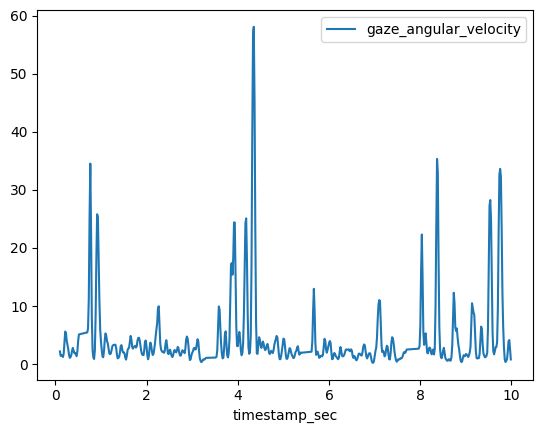

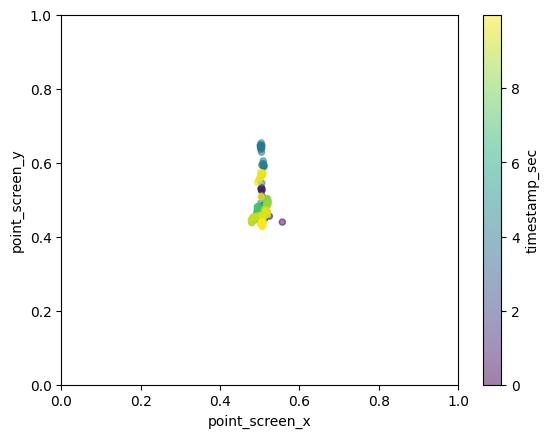

In [171]:
gaze_df.plot(x="timestamp_sec", y="gaze_angular_velocity")

preprocessed_window_df.plot(kind='scatter', x='point_screen_x', y='point_screen_y', alpha=0.5, c='timestamp_sec', cmap='viridis', xlim=(0,1), ylim=(0,1))



In [185]:
import tqdm
reload(cwfeat)

NBACK_DATASET_DIR = Path(cwpre.__file__).parents[2] / "datasets" / "NBACK"
TASKS = [1,2,3]
TRIALS = [1,2,3,4]
SUBJECT_EXCLUSION = ["ERK0"]

# First, extract all subjects UID (folder names under NBACK_DATASET_DIR)
subject_uids = [d.name for d in NBACK_DATASET_DIR.iterdir() if d.is_dir()]
subject_uids = [subject_id for subject_id in subject_uids if subject_id not in SUBJECT_EXCLUSION]
subject_uids = ['BEN0']

# Then, for each subject, load their data
all_eye_df = cwpre.load_nback_dataset(NBACK_DATASET_DIR, subject_uids, TASKS, TRIALS)

all_eye_data_grouped = all_eye_df.groupby(['subject_id', 'task_id', 'trial_id'])
# Extract all window features
Fs = 60
WINDOW_N = 600 # 10 seconds at 60Hz
WINDOW_STEP = 60
SKIP_EDGE_SAMPLES = Fs # first & last second are discarded

skipped_windows = None
skip_window_counter = 0

features_df = pd.DataFrame()
for (subject_id, task_id, trial_id), group_df in tqdm.tqdm(all_eye_data_grouped, desc="Extracting features"):
    feature_rows = []
    # Discard edge samples
    group_df = group_df.iloc[SKIP_EDGE_SAMPLES:-SKIP_EDGE_SAMPLES].sort_values('timestamp_sec')
    
    # Extract features in sliding windows
    for start in range(WINDOW_N, len(group_df), WINDOW_STEP):
        window_df = group_df.iloc[start - WINDOW_N:start].reset_index(drop=True)
        window_preprocess_df, window_gaze_df, window_pupil_df, window_gaps_df = cwpre.preprocess_nback_data(window_df, verbose=False)
        if window_preprocess_df['low_confidence_percentage'].iloc[0] > 30:
            t_start = window_preprocess_df['timestamp_sec'].min()
            t_end = window_preprocess_df['timestamp_sec'].max()
            #print(f"Skipping window [{t_start:.2f}, {t_end:.2f}] due to low confidence percentage of {window_preprocess_df['low_confidence_percentage'].iloc[0]:.2f}%")
            skip_window_counter += 1
            window_preprocess_df['skip_id'] = skip_window_counter
            skipped_windows = pd.concat([skipped_windows, window_preprocess_df], ignore_index=True) if skipped_windows is not None else window_preprocess_df
            continue

        # Extract features
        try:
            features = cwfeat.extract_window_features(
                window_preprocess_df, 
                window_gaze_df, 
                window_pupil_df, 
                window_gaps_df, 
                ivt_threshold=30, 
                min_fixation_duration=55, 
                verbose=False
            )
        except Exception as e:
            print(f"Error extracting features for window in subject {subject_id}, task {task_id}: {e}")
            continue
        features['bad_samples_ratio'] = window_preprocess_df['low_confidence_percentage'].mean()
        features['subject_id'] = subject_id
        features['task_id'] = task_id
        features['trial_id'] = trial_id
        features['nback_level'] = window_preprocess_df['nback_level'].iloc[0]
        feature_rows.append(features)
    
    features_df = pd.concat([features_df, pd.DataFrame(feature_rows)], ignore_index=True)
    # if subject_id > 5:
    #     break

print(f"Extracted features for {len(features_df)} windows.")
print(f"Skipped {skip_window_counter} windows due to low confidence percentage.")

Loading subjects:   0%|          | 0/1 [00:00<?, ?it/s]

Extracting features: 100%|██████████| 12/12 [01:39<00:00,  8.26s/it]

Extracted features for 452 windows.
Skipped 0 windows due to low confidence percentage.


In [186]:
features_df.head()

,fixations_count,fixations_duration_mean,fixations_duration_max,fixations_duration_min,fixations_duration_skew,fixations_duration_kurt,fixations_duration_std,saccades_count,blinks_count,blinks_duration_max,...,saccades_amplitude_min,saccades_amplitude_skew,saccades_amplitude_kurt,saccades_amplitude_std,saccades_duration_mean,saccades_duration_max,saccades_duration_min,saccades_duration_skew,saccades_duration_kurt,saccades_duration_std
0,1,8335.00,8335.00,8335.00,NaN,NaN,0.000000,0,0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,9035.14,9035.14,9035.14,NaN,NaN,0.000000,0,0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1,9735.28,9735.28,9735.28,NaN,NaN,0.000000,0,0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,6,1616.99,4184.17,50.01,1.071477,1.128181,1484.622376,5,0,0.0,...,0.765719,-0.940282,0.789438,0.159073,23.338,33.34,16.67,0.608581,-3.333333,9.130535
4,1,9968.66,9968.66,9968.66,NaN,NaN,0.000000,0,0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
